In [1]:
#> imports
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

#> colossus
from colossus.lss import mass_function
from colossus.cosmology import cosmology as ccos

#> module imports
sys.path.insert(1, '../.')
import priors
import cosmology
from modules.units import u; u=u()

#> declarations
fontsize = 15
labelpad = 10

### ***Opus Priors***

---

The file documenting the priors can be found in 'C:\Users\mille\Desktop\Research\+knowledge\+project_notes\opus\priors.md'

The equations are implemented in '/Opus/params.py'

There are four priors implemented in Opus (currently):
1. Halo Mass Function
2. Mass-Concentration Relation
3. Stellar-to-Halo Mass Relation
4. Stellar Mass-Size Relation

### ***1. Halo Mass Function***

---

$$
\begin{align}
f(M)dM &= f(\nu)d\nu \\ \\
\nu &\equiv \frac{\delta^2_c(z)}{\sigma^2(M)} \\ \\
\sigma^2(M,k) &= \int\frac{dk}{k} \frac{k^3P_{lin}(k,z)}{2\pi^2} W^2[kR(M)] \\ \\
\nu f(\nu) &= A \left( 1 +\frac{1}{\nu^{\prime p}} \right) \left( \frac{\nu^\prime}{2\pi^2} \right)^{1/2} \exp(-\nu^\prime/2) \\ \\
\nu^\prime &= a \nu
\end{align}
$$
where $P_{lin}(k,z)$ is the initial power spectrum extrapolated to redshift $z$ using linear theory, $W(x) \equiv 3j_i(x)/x$ is the smoothing filter, and $R(M)$ is given by the requirement $M/(4\pi R^3/3) = \rho_b$ (where $\rho_b$ is comoving). The Colossus code calculates $\frac{dn}{dlnM}$ and my code converts it to a CDF to sample from. The coefficients used in Colossus Despali 16 are (EQ 12):
$$
\begin{align}
x &= log[\Delta(z) / \Delta_{vir}(z)] \\
a &= 0.4332x^2 + 0.2263x + 0.7665 \\ 
p &= -0.1151x^2 + 0.2554x + 0.2488 \\ 
A &= -0.1362x + 0.3292 
\end{align}
$$

***Cumulative Distribution Function (CDF):***
$$
P(lnM|z_l) = \frac{\frac{dn}{dlnM}(M,z_l)}{\int^{lnM_{max}}_{lnM_{min}} \frac{dn}{dlnM}(M^\prime,z_l)dlnM}
$$

In [2]:
#> declarations
zl = 0.5
cosmo = u.cosmo
h  = u.cosmo['h0'] / 100

#> cosmology declaration
ccosmo = ccos.setCosmology('myCosmo', 
                           params=ccos.cosmologies['planck18'], # initial base cosmology (keeps Ob0, sigma8, and ns)
                           H0 =cosmo['h0'],            # H0
                           Om0=cosmo['omega_m_0'],     # omega_m_0
                           relspecies=True,            # allows for non-zero omega_gamma
                           flat=True)                  # ignores Ode0

#> calculates the halo mass function cdf at a given redshift
def halo_cdf(zl, h, log10Mmin=11.5, log10Mmax=14.5, mdef='vir', ngrid=4096):

    #> logarithmic mass grid
    lnMmin = np.log(h * 10**log10Mmin)       # changing to solM/h and base e
    lnMmax = np.log(h * 10**log10Mmax)       # changing to solM/h and base e
    lnm = np.linspace(lnMmin, lnMmax, ngrid) # grid in base e
    mass_h = np.exp(lnm)                     # changing to Msol/h
    
    #> mass function ( returns dn/d[ln(solM/h)] per ln(solM/h) )
    dndlnm = mass_function.massFunction(x=mass_h,          # solM/h bins
                                        z=zl,              # lens redshift
                                        q_in='M',          # in mass = solM/h (halo masses)
                                        q_out='dndlnM',    # out mass = dn/dlnM(solM/h)
                                        mdef=mdef,         # halo mass definition
                                        model='despali16', # model for mass function
                                        ellipsoidal=False) # If True, return the results for an ellipsoidal halo finder, otherwise standard SO.
    
    #> removing nans and infs
    dndlnm = np.asarray(dndlnm)
    dndlnm[~np.isfinite(dndlnm)] = 0
    dndlnm[dndlnm < 0] = 0
    
    #> integrating in ln(mass)
    cdf = cumulative_trapezoid(dndlnm, lnm, initial=0) # integrating full curve
    if cdf[-1] <= 0: error.phrase('HMF is zero over the selected mass range!')
    cdf /= cdf[-1] # normalizing based on total comoving numer density of halos in the selected mass interval
                   # i.e., normalizing between (0, 1)
    
    #> removing repeated values in the high-mass tail
    #> i.e., keeping only positively increasing cdf values
    keep = np.concatenate(([True], np.diff(cdf) > 0)) 
    lnm, cdf = lnm[keep], cdf[keep]
    cdf[-1] = 1

    return lnm, cdf, dndlnm

lnm, cdf, dndlnm = halo_cdf(zl, h, log10Mmin=11.5, log10Mmax=14.5, mdef='vir', ngrid=4096)

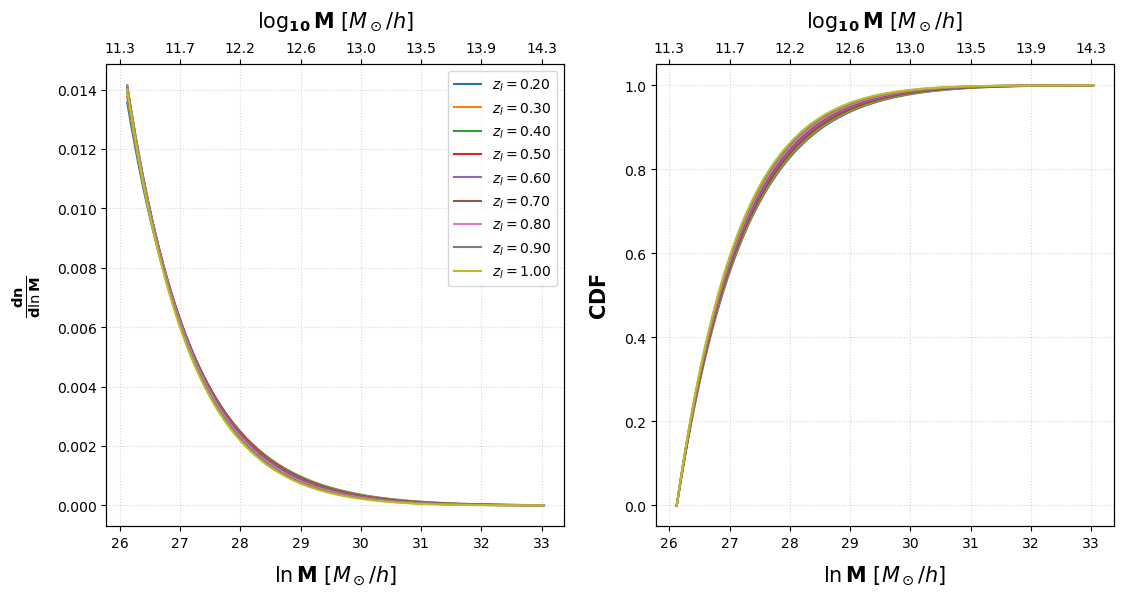

In [3]:
#> declarations
zls = np.linspace(0.2, 1.0, 9)

#> initializing plot
fig, axes = plt.subplots(1,2,figsize=(13,6))

def tick_function(X):
    V = np.log10(np.exp(X))
    return ["%.2f" % z for z in V]

for i, ax in enumerate(axes.flat):

    ax.grid(ls=':', alpha=0.5)

    if i == 0:

        ax.set_xlabel(r'$\mathbf{\ln M} ~[M_\odot/h]$', fontsize=fontsize, labelpad=labelpad)
        ax.set_ylabel(r'$\mathbf{\frac{dn}{d\ln M}}$', fontsize=fontsize, labelpad=labelpad)

        for zl in zls:
            lnm, cdf, dndlnm = halo_cdf(zl, h)
            ax.plot(lnm, dndlnm, label=fr'$z_l=${zl:.2f}')

        ax.legend()

    if i == 1:

        ax.set_xlabel(r'$\mathbf{\ln M} ~[M_\odot/h]$', fontsize=fontsize, labelpad=labelpad)
        ax.set_ylabel(r'$\mathbf{CDF}$', fontsize=fontsize, labelpad=labelpad)

        for zl in zls:
            lnm, cdf, dndlnm = halo_cdf(zl, h)
            ax.plot(lnm, cdf)

    #> adding top x-axis
    ax2 = ax.twiny()
    ax2.set_xticks(ax.get_xticks())
    ax2.set_xbound(ax.get_xbound())
    ax2.set_xticklabels([f'{np.log10(np.exp(x)):.1f}' for x in ax.get_xticks()])
    ax2.set_xlabel(r'$\mathbf{\log_{10} M} ~[M_\odot/h]$', fontsize=fontsize, labelpad=labelpad)

### ***2. Mass-Concentration Relation***

---

$$
\begin{align}
\log_{10}c_{vir} &=a+b\log_{10}(M_{vir}/[10^{12}h^{-1}M_\odot]) \\ \\
a &= 0.537 + (1.025-0.537)\exp(-0.718z^{1.08}) \\ \\
b &= -0.097 + 0.024z
\end{align}
$$

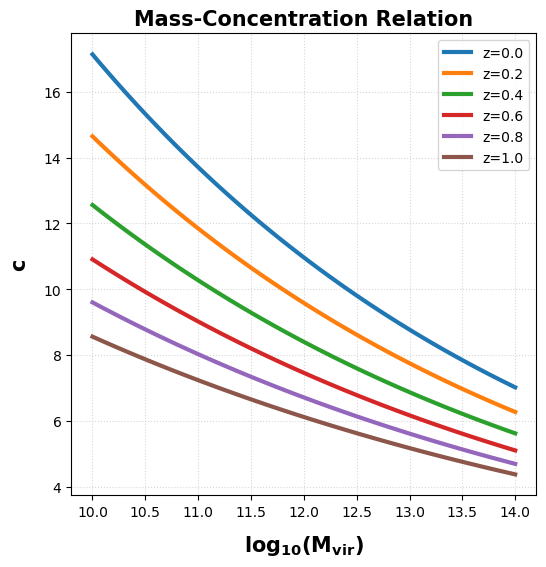

In [4]:
#> declarations
h = u.cosmo['h0'] / 100

#> params
log_M_vir = np.linspace(10, 14, 100)
M_vir = np.array([10**x for x in log_M_vir])
zl = np.linspace(0, 1, 6)

#> initializing plot
fig, ax = plt.subplots(1,1,figsize=(6,6))
ax.grid(ls=':', alpha=0.5)
ax.set_title('Mass-Concentration Relation', fontsize=fontsize, fontweight='bold')
ax.set_xlabel(r'$\mathbf{log_{10}(M_{vir})}$', fontsize=fontsize, labelpad=labelpad)
ax.set_ylabel(r'$\mathbf{c}$', fontsize=fontsize, labelpad=labelpad)

for z in zl:
    ax.plot(log_M_vir, priors.mass_c_vir_rel(M_vir, [z]*len(M_vir), cosmo), lw=3, label=f'z={z:.1f}')

plt.legend()
plt.show()

### ***3. Stellar-to-Halo Mass Relation***

---

$$
\begin{align}
&log\left(f^{-1}_{SHMR}(M_*)\right) = log(M_h) \\
&=log(M_1) + \beta ~log\left(\frac{M_*}{M_{*,0}}\right) + \frac{\left(\frac{M_*}{M_{*,0}}\right)^\delta}{1+\left(\frac{M_*}{M_{*,0}}\right)^{-\gamma}} - \frac{1}{2}
\end{align}
$$
where $M_1$ controls the normalization of $M_h$ as a function of $M_*$ and $M_{*,0}$ controls the position along the $M_*$-axis. Together, (the) two parameters govern the transition mass scale between the low-mass and high-mass regime of the SHMR. The low-mass regime ($M_* \leq 10^{10.5} M_\odot$) is described by a power-law regulated by the parameter $\beta$. The high-mass regime follows a sub-exponential law regulated by the parameter $\delta$, and the transition regime is shaped by the parameter $\gamma$. The coefficients $M_1, M_{*,0}, \beta, \delta, \gamma$ are fit within redshift bins and their values are given in Table F.1 of 2022 Shuntov. There is an additional parameter, $\sigma_{log(M)}$, which is the error in the stellar mass (I believe) and will be used later.

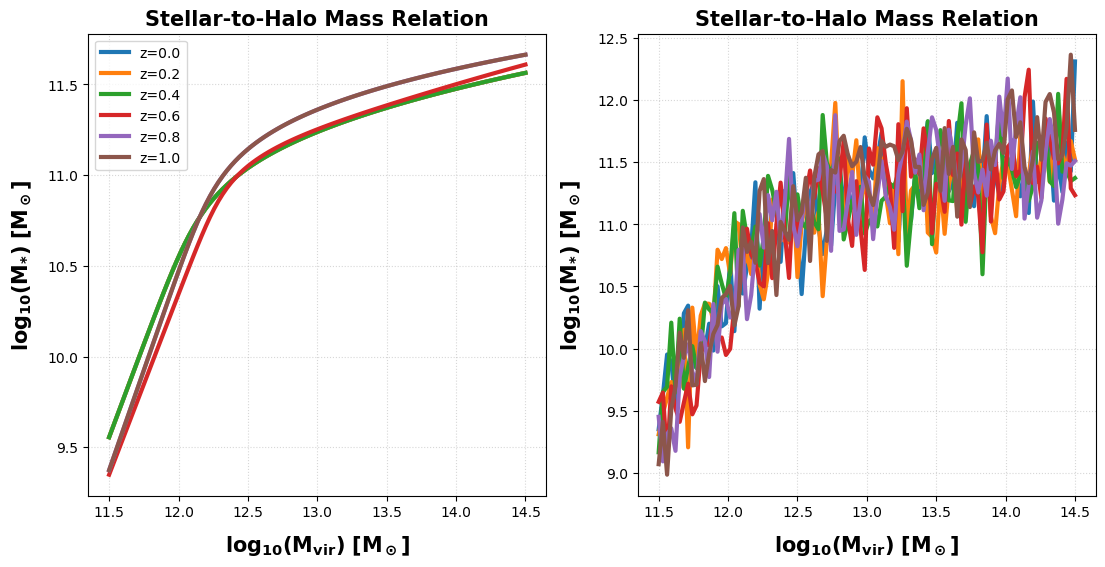

In [5]:
#> declarations
log10Mmin = 11.5 
log10Mmax = 14.5
log_M_vir = np.linspace(log10Mmin, log10Mmax, 100)
M_virs = np.array([10**x for x in log_M_vir])
zls = np.linspace(0.2, 1.0, 10)

#> initializing plot
fig, axes = plt.subplots(1,2,figsize=(13,6))

for i, ax in enumerate(axes.flat):
    
    ax.grid(ls=':', alpha=0.5)
    ax.set_title('Stellar-to-Halo Mass Relation', fontsize=fontsize, fontweight='bold')
    ax.set_xlabel(r'$\mathbf{log_{10}(M_{vir}) ~[M_\odot]}$', fontsize=fontsize, labelpad=labelpad)
    ax.set_ylabel(r'$\mathbf{log_{10}(M_{*}) ~[M_\odot]}$', fontsize=fontsize, labelpad=labelpad)

    if i == 0: 
        for z in zl:
            ax.plot(log_M_vir, np.log10(priors.stellar_h_mass_rel(M_virs, [z]*len(M_virs), sigma_logM=0.0)), lw=3, label=f'z={z:.1f}', alpha=1.0)
        ax.legend()

    if i == 1: 
        for z in zl:
            ax.plot(log_M_vir, np.log10(priors.stellar_h_mass_rel(M_virs, [z]*len(M_virs))), lw=3, label=f'z={z:.1f}', alpha=1.0)

plt.show()

### ***4. Stellar Mass-Size Relation***
---

$$
\begin{align}
\log R_{eff} &\sim N(\log R_{eff}, \sigma_{\log r}) \\ \\
\frac{\log R_{eff}}{kpc} &= \log b + a \log\left(\frac{M_*}{10^{10}M_\odot}\right) \\ \\
a &= \beta_a (1+z)^{\alpha_a} \\ \\
b &= \beta_b (1+z)^{\alpha_b} \\ \\
\sigma_{\log r} &= \sigma_\perp \sqrt{1+a^2}
\end{align}
$$
where $(\alpha_a, \beta_a)$ and $(\alpha_b, \beta_b)$ are taken from Table 4 of 2025 Cook for spheroid-dominated galaxies. The perpendicular log-error $\sigma_{\perp}$ is not given as a function of redshift, but is quoted as being $\sigma_{\perp} = 0.158$ dex for spheroid-dominated galaxies below Eq. 6. The conversion between $\sigma_\perp$ and $\sigma_{\log r}$ is given above.

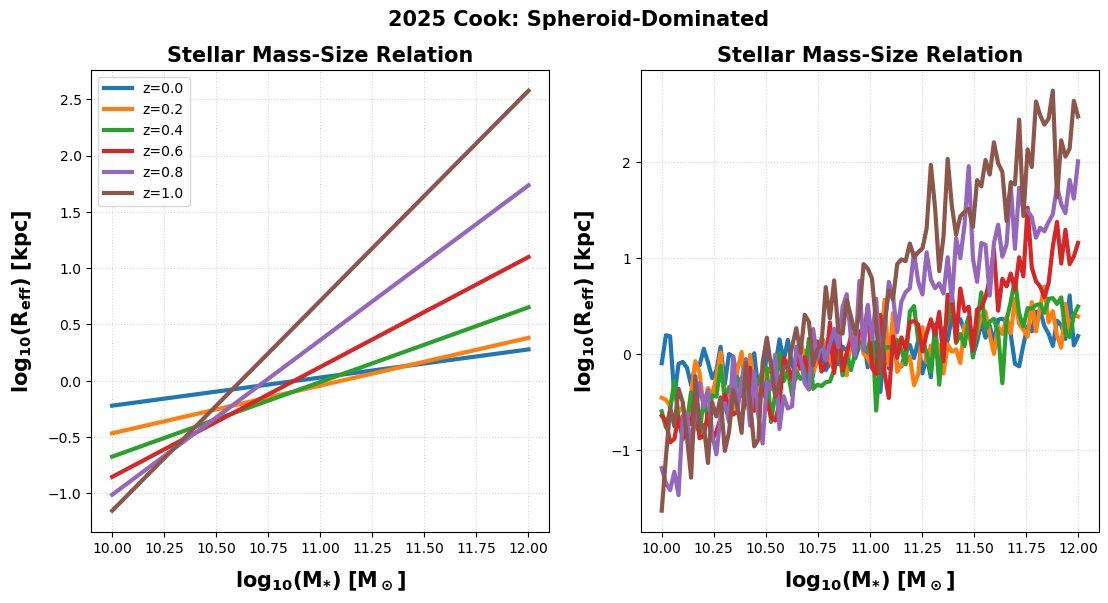

In [10]:
#> declarations
log10Mmin = 10
log10Mmax = 12
log_M_star = np.linspace(log10Mmin, log10Mmax, 100)
M_stars = np.array([10**x for x in log_M_star])
zls = np.linspace(0.2, 1.0, 10)

#> initializing plot
fig, axes = plt.subplots(1,2,figsize=(13,6))
plt.suptitle('2025 Cook: Spheroid-Dominated', fontsize=fontsize, fontweight='bold')

for i, ax in enumerate(axes.flat):
    
    ax.grid(ls=':', alpha=0.5)
    ax.set_title('Stellar Mass-Size Relation', fontsize=fontsize, fontweight='bold')
    ax.set_xlabel(r'$\mathbf{log_{10}(M_{*}) ~[M_\odot]}$', fontsize=fontsize, labelpad=labelpad)
    ax.set_ylabel(r'$\mathbf{log_{10}(R_{eff}) ~[kpc]}$', fontsize=fontsize, labelpad=labelpad)

    if i == 0: 
        for z in zl:
            ax.plot(log_M_star, np.log10(priors.mass_r_relation(M_stars, [z]*len(M_stars), morph='spheroid-dominated', sigma_log_R_eff=0.0)), lw=3, label=f'z={z:.1f}', alpha=1.0)
        ax.legend()

    if i == 1: 
        for z in zl:
            ax.plot(log_M_star, np.log10(priors.mass_r_relation(M_stars, [z]*len(M_stars), morph='spheroid-dominated')), lw=3, label=f'z={z:.1f}', alpha=1.0)

plt.show()

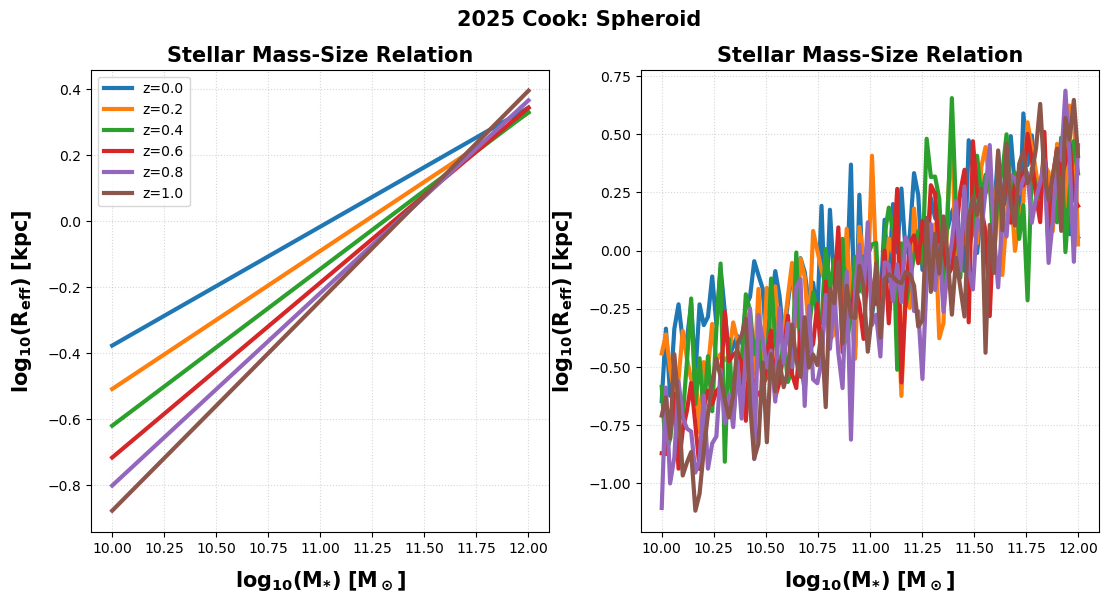

In [11]:
#> initializing plot
fig, axes = plt.subplots(1,2,figsize=(13,6))
plt.suptitle('2025 Cook: Spheroid', fontsize=fontsize, fontweight='bold')

for i, ax in enumerate(axes.flat):
    
    ax.grid(ls=':', alpha=0.5)
    ax.set_title('Stellar Mass-Size Relation', fontsize=fontsize, fontweight='bold')
    ax.set_xlabel(r'$\mathbf{log_{10}(M_{*}) ~[M_\odot]}$', fontsize=fontsize, labelpad=labelpad)
    ax.set_ylabel(r'$\mathbf{log_{10}(R_{eff}) ~[kpc]}$', fontsize=fontsize, labelpad=labelpad)

    if i == 0: 
        for z in zl:
            ax.plot(log_M_star, np.log10(priors.mass_r_relation(M_stars, [z]*len(M_stars), morph='spheroid', sigma_log_R_eff=0.0)), lw=3, label=f'z={z:.1f}', alpha=1.0)
        ax.legend()

    if i == 1: 
        for z in zl:
            ax.plot(log_M_star, np.log10(priors.mass_r_relation(M_stars, [z]*len(M_stars), morph='spheroid')), lw=3, label=f'z={z:.1f}', alpha=1.0)

plt.show()